# Peta Kerentanan Biaya Hidup terhadap Dinamika Pasar Kerja dan Pertumbuhan Ekonomi
## 1. PEMBERSIHAN DATA & PENANGANAN MISSING VALUES SECARA REALISTIS

Langkah-langkah:
1. **Konversi Karakter & Tipe Data**: Mengubah nilai '-' atau kosong menjadi `np.nan` dan menghilangkan pemisah ribuan.
2. **Restrukturisasi Header**: Menyatukan header bertingkat yang berantakan dari Excel BPS.
3. **Agregasi TPT**: Menghitung rata-rata tahunan TPT dari rilis Februari dan Agustus.
4. **Imputasi DOB Papua**: Imputasi historis untuk DOB Papua dari provinsi induknya (Papua dan Papua Barat) sebelum proses melting.
5. **Imputasi Klaster Regional**: _Group Mean Imputation_ berbasis klaster kepulauan untuk nilai NaN lainnya.
6. **Standardisasi Teks**: Memastikan nama 38 Provinsi sinkron dan memisahkan baris 'INDONESIA' ke DataFrame terpisah.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Membuat direktori jika belum ada
os.makedirs('../data/processed', exist_ok=True)



### 1.1 Memuat Data dengan Custom Parser Header BPS
Data Excel BPS memiliki struktur _header_ yang tidak standar (berada di baris 0, 1, 2, dll). Kita menggunakan pembacaan `header=None` lalu merestrukturisasi kolomnya dengan presisi tinggi.


In [8]:
def clean_val(x):
    if pd.isna(x) or str(x).strip() in ['-', '', '.', '..', 'nan']:
        return np.nan
    return x

def load_gk_wide(path):
    df = pd.read_excel(path, header=None)
    prov = df.iloc[4:, 0].astype(str).str.strip().str.upper().values
    tipe = df.iloc[1, 1:].ffill().astype(str).str.lower().values
    tahun = df.iloc[2, 1:].astype(str).str.extract(r'(\d{4})')[0].values
    cols = [f"{t}_{y}" for t, y in zip(tipe, tahun)]
    
    data = df.iloc[4:, 1:].values
    df_wide = pd.DataFrame(data, columns=cols)
    df_wide.insert(0, 'Provinsi', prov)
    return df_wide

def load_tpt_wide(path):
    df = pd.read_excel(path, header=None)
    prov = df.iloc[3:, 0].astype(str).str.strip().str.upper().values
    tahun = df.iloc[1, 1:].ffill().astype(str).str.extract(r'(\d{4})')[0].values
    bulan = df.iloc[2, 1:].astype(str).str.lower().values
    cols = [f"{b}_{y}" for b, y in zip(bulan, tahun)]
    
    data = df.iloc[3:, 1:].values
    df_wide = pd.DataFrame(data, columns=cols)
    df_wide.insert(0, 'Provinsi', prov)
    return df_wide

def load_pdrb_wide(path):
    df = pd.read_excel(path, header=None)
    prov = df.iloc[2:, 0].astype(str).str.strip().str.upper().values
    tahun = df.iloc[1, 1:].astype(str).str.extract(r'(\d{4})')[0].values
    cols = [str(y) for y in tahun]
    
    data = df.iloc[2:, 1:].values
    df_wide = pd.DataFrame(data, columns=cols)
    df_wide.insert(0, 'Provinsi', prov)
    return df_wide

path_gk = '../data/raw/Garis Kemiskinan Perkotaan & Perdesaan.xlsx'
path_tpt = '../data/raw/Tingkat Pengangguran Terbuka TPT rilis Februari & Agustus.xlsx'
path_pdrb = '../data/raw/Laju Pertumbuhan PDRB Seri 2010.xlsx'

df_gk_wide = load_gk_wide(path_gk).map(clean_val)
df_tpt_wide = load_tpt_wide(path_tpt).map(clean_val)
df_pdrb_wide = load_pdrb_wide(path_pdrb).map(clean_val)

# Hapus baris dengan Provinsi NaN
for df_temp in [df_gk_wide, df_tpt_wide, df_pdrb_wide]:
    df_temp.dropna(subset=['Provinsi'], inplace=True)
    df_temp.drop(df_temp[df_temp['Provinsi'] == 'NAN'].index, inplace=True)



### 1.2 Pemisahan Agregat Nasional (INDONESIA)


In [9]:
df_gk_indo = df_gk_wide[df_gk_wide['Provinsi'] == 'INDONESIA'].copy()
df_gk_wide = df_gk_wide[df_gk_wide['Provinsi'] != 'INDONESIA'].copy()

df_tpt_indo = df_tpt_wide[df_tpt_wide['Provinsi'] == 'INDONESIA'].copy()
df_tpt_wide = df_tpt_wide[df_tpt_wide['Provinsi'] != 'INDONESIA'].copy()

df_pdrb_indo = df_pdrb_wide[df_pdrb_wide['Provinsi'] == 'INDONESIA'].copy()
df_pdrb_wide = df_pdrb_wide[df_pdrb_wide['Provinsi'] != 'INDONESIA'].copy()



### 1.3 Imputasi DOB Papua (Sebelum Melting)
Terdapat 4 Daerah Otonom Baru (PAPUA TENGAH, PAPUA PEGUNUNGAN, PAPUA SELATAN, PAPUA BARAT DAYA) yang belum memiliki nilai pada tahun 2021-2023. Kita mengimputasinya dengan nilai provinsi induknya.


In [10]:
def impute_dob_papua(df):
    dob_map = {
        'PAPUA BARAT DAYA': 'PAPUA BARAT',
        'PAPUA TENGAH': 'PAPUA',
        'PAPUA PEGUNUNGAN': 'PAPUA',
        'PAPUA SELATAN': 'PAPUA'
    }
    df = df.set_index('Provinsi')
    
    # Tambahkan baris DOB jika belum ada
    for dob in dob_map.keys():
        if dob not in df.index:
            df.loc[dob] = np.nan
            
    # Imputasi
    for dob, induk in dob_map.items():
        if induk in df.index and dob in df.index:
            df.loc[dob] = df.loc[dob].fillna(df.loc[induk])
            
    return df.reset_index()

df_gk_wide = impute_dob_papua(df_gk_wide)
df_tpt_wide = impute_dob_papua(df_tpt_wide)
df_pdrb_wide = impute_dob_papua(df_pdrb_wide)



### 1.4 Transformasi Wide ke Long Format & Agregasi TPT


In [11]:
# 1. Garis Kemiskinan
df_gk_long = pd.melt(df_gk_wide, id_vars=['Provinsi'], var_name='Tipe_Tahun', value_name='Nilai')
df_gk_long[['Tipe', 'Tahun']] = df_gk_long['Tipe_Tahun'].str.split('_', expand=True)

# Pastikan numerik
df_gk_long['Nilai'] = pd.to_numeric(df_gk_long['Nilai'].astype(str).str.replace(',', '.'), errors='coerce')

df_gk_long['GK_Urban'] = np.where(df_gk_long['Tipe'].str.contains('kota'), df_gk_long['Nilai'], np.nan)
df_gk_long['GK_Rural'] = np.where(df_gk_long['Tipe'].str.contains('desa'), df_gk_long['Nilai'], np.nan)

# Agregasi untuk menghilangkan NaN di kolom yang berbeda
df_gk_final = df_gk_long.groupby(['Provinsi', 'Tahun']).agg({
    'GK_Urban': 'first',
    'GK_Rural': 'first'
}).reset_index()


# 2. TPT
df_tpt_long = pd.melt(df_tpt_wide, id_vars=['Provinsi'], var_name='Bulan_Tahun', value_name='TPT')
df_tpt_long[['Bulan', 'Tahun']] = df_tpt_long['Bulan_Tahun'].str.split('_', expand=True)
df_tpt_long['TPT'] = pd.to_numeric(df_tpt_long['TPT'].astype(str).str.replace(',', '.'), errors='coerce')

# Rata-rata tahunan (Februari & Agustus)
df_tpt_final = df_tpt_long.groupby(['Provinsi', 'Tahun'])['TPT'].mean().reset_index()


# 3. PDRB
df_pdrb_final = pd.melt(df_pdrb_wide, id_vars=['Provinsi'], var_name='Tahun', value_name='Laju_PDRB')
df_pdrb_final['Laju_PDRB'] = pd.to_numeric(df_pdrb_final['Laju_PDRB'].astype(str).str.replace(',', '.'), errors='coerce')



## 2. INTEGRASI DATA (Merging) & Imputasi Fallback


In [12]:
# Menggabungkan ketiga DataFrame
df_merge1 = pd.merge(df_pdrb_final, df_tpt_final, on=['Provinsi', 'Tahun'], how='outer')
df_final = pd.merge(df_merge1, df_gk_final, on=['Provinsi', 'Tahun'], how='outer')

# Hanya mengambil rentang tahun yang valid (Misal: 2021 - 2025)
df_final = df_final.dropna(subset=['Tahun'])
df_final = df_final[df_final['Tahun'].isin(['2021', '2022', '2023', '2024', '2025'])]

# 1.5 Imputasi Klaster Regional (Fallback)
def assign_island_cluster(prov):
    prov = str(prov)
    if any(x in prov for x in ['SUMATERA', 'ACEH', 'RIAU', 'JAMBI', 'BENGKULU', 'BANGKA', 'LAMPUNG']):
        return 'Sumatera'
    elif any(x in prov for x in ['JAWA', 'BANTEN', 'DKI', 'YOGYAKARTA']):
        return 'Jawa'
    elif 'KALIMANTAN' in prov:
        return 'Kalimantan'
    elif any(x in prov for x in ['SULAWESI', 'GORONTALO']):
        return 'Sulawesi'
    elif any(x in prov for x in ['MALUKU', 'PAPUA']):
        return 'Maluku-Papua'
    elif any(x in prov for x in ['BALI', 'NUSA']):
        return 'Bali-Nusa Tenggara'
    return 'Lainnya'

df_final['Klaster_Pulau'] = df_final['Provinsi'].apply(assign_island_cluster)

# Group Mean Imputation berdasarkan Klaster dan Tahun
num_cols = ['Laju_PDRB', 'TPT', 'GK_Urban', 'GK_Rural']

# Kita cek dulu apakah df_final punya isi untuk mencegah ValueError: No objects to concatenate
if not df_final.empty:
    df_final[num_cols] = df_final.groupby(['Klaster_Pulau', 'Tahun'])[num_cols].transform(lambda x: x.fillna(x.mean()))

    # Jika masih ada NaN (misal 1 klaster NaN semua), fillna dengan rata-rata nasional tahun tersebut
    df_final[num_cols] = df_final.groupby('Tahun')[num_cols].transform(lambda x: x.fillna(x.mean()))

# Mengatur urutan kolom akhir
final_columns = ['Provinsi', 'Tahun', 'Laju_PDRB', 'TPT', 'GK_Urban', 'GK_Rural', 'Klaster_Pulau']
df_final = df_final[final_columns].sort_values(['Provinsi', 'Tahun']).reset_index(drop=True)

# Ekspor Data
export_path = '../data/processed/poverty_macro_clean.csv'
df_final.to_csv(export_path, index=False)
print(f"Data final berhasil diekspor ke: {export_path}")
df_final.head()



Data final berhasil diekspor ke: ../data/processed/poverty_macro_clean.csv


,Provinsi,Tahun,Laju_PDRB,TPT,GK_Urban,GK_Rural,Klaster_Pulau
0,ACEH,2021,2.81,6.300,565776.0,529035.0,Sumatera
1,ACEH,2022,4.21,6.070,606394.0,565762.0,Sumatera
2,ACEH,2023,4.23,5.890,657772.0,612007.0,Sumatera
3,ACEH,2024,4.66,5.655,696048.0,643398.0,Sumatera
4,ACEH,2025,2.97,5.570,716522.0,655435.0,Sumatera


## 3. INTERACTIVE EDA
### 3.1 Matriks Korelasi (Correlation Heatmap)


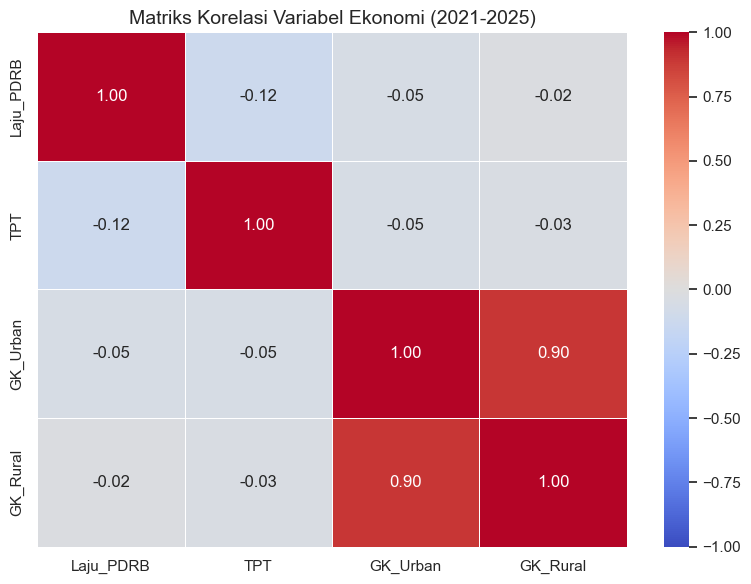

In [13]:
# Set style
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(8, 6))

# Hitung korelasi
corr = df_final[['Laju_PDRB', 'TPT', 'GK_Urban', 'GK_Rural']].corr()

# Tampilkan Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Matriks Korelasi Variabel Ekonomi (2021-2025)', fontsize=14)
plt.tight_layout()
plt.show()



### 3.2 Temuan Anomali secara Terprogram


In [14]:
print("=== TOP 3 ANOMALI MENARIK ===")

# Anomali 1: Biaya hidup perdesaan > perkotaan
anomali_1 = df_final[df_final['GK_Rural'] > df_final['GK_Urban']].copy()
if not anomali_1.empty:
    print(f"\n1. Kasus Garis Kemiskinan Perdesaan > Perkotaan ditemukan di {len(anomali_1)} observasi:")
    print(anomali_1[['Provinsi', 'Tahun', 'GK_Urban', 'GK_Rural']].head(3).to_string(index=False))
else:
    print("\n1. Tidak ditemukan kasus GK Perdesaan > Perkotaan.")

if not df_final.empty and not df_final['Laju_PDRB'].isna().all():
    # Anomali 2: Laju PDRB tinggi (> rata-rata nasional) tetapi TPT sangat tinggi (> persentil 90)
    pdrb_mean = df_final['Laju_PDRB'].mean()
    tpt_p90 = df_final['TPT'].quantile(0.90)

    anomali_2 = df_final[(df_final['Laju_PDRB'] > pdrb_mean) & (df_final['TPT'] > tpt_p90)]
    if not anomali_2.empty:
        print(f"\n2. Provinsi dengan PDRB tumbuh di atas rata-rata ({pdrb_mean:.2f}) tapi Pengangguran sangat tinggi (>{tpt_p90:.2f}):")
        print(anomali_2[['Provinsi', 'Tahun', 'Laju_PDRB', 'TPT']].head(3).to_string(index=False))

    # Anomali 3: Garis kemiskinan meroket (Kenaikan YoY tertinggi)
    df_final['GK_Total_Mean'] = df_final[['GK_Urban', 'GK_Rural']].mean(axis=1)
    df_sorted = df_final.sort_values(['Provinsi', 'Tahun'])
    df_sorted['GK_Growth'] = df_sorted.groupby('Provinsi')['GK_Total_Mean'].pct_change() * 100

    anomali_3 = df_sorted.sort_values('GK_Growth', ascending=False).head(3)
    print("\n3. Lonjakan Garis Kemiskinan (YoY %) Tertinggi:")
    print(anomali_3[['Provinsi', 'Tahun', 'GK_Total_Mean', 'GK_Growth']].to_string(index=False))
else:
    print("\nData tidak mencukupi untuk mendeteksi anomali 2 dan 3.")



=== TOP 3 ANOMALI MENARIK ===

1. Kasus Garis Kemiskinan Perdesaan > Perkotaan ditemukan di 12 observasi:
         Provinsi Tahun  GK_Urban  GK_Rural
KALIMANTAN TENGAH  2021  494153.0  514743.0
KALIMANTAN TENGAH  2022  525228.0  565361.0
KALIMANTAN TENGAH  2023  570559.0  613490.0

2. Provinsi dengan PDRB tumbuh di atas rata-rata (5.35) tapi Pengangguran sangat tinggi (>6.71):
  Provinsi Tahun  Laju_PDRB  TPT
JAWA BARAT  2022       5.45 8.33

3. Lonjakan Garis Kemiskinan (YoY %) Tertinggi:
        Provinsi Tahun  GK_Total_Mean  GK_Growth
PAPUA PEGUNUNGAN  2024      1138147.0  61.986714
    PAPUA TENGAH  2024       817187.0  16.306098
PAPUA PEGUNUNGAN  2025      1284721.0  12.878301


### 3.3 Rekomendasi Skema Tabel untuk Google Looker Studio
Data `poverty_macro_clean.csv` siap dihubungkan langsung ke Google Looker Studio.
Rekomendasi konfigurasi tipe data saat import:
- **Provinsi**: Geo > Region (untuk visualisasi peta)
- **Tahun**: Date & Time > Year (YYYY) (sebagai dimensi temporal)
- **Klaster_Pulau**: Text (untuk Filter/Control)
- **Laju_PDRB**: Number > Percent (jika data dalam persentase absolut)
- **TPT**: Number > Percent
- **GK_Urban / GK_Rural**: Number > Currency (IDR)

*Tips Looker Studio:*
Buat parameter/filter interaktif untuk 'Tahun' dan 'Klaster Pulau' di header dashboard. Gunakan _Filled Map_ (Peta Choropleth) berbasis 'Provinsi' dengan metrik TPT atau PDRB untuk menunjukkan kerentanan spasial secara instan.

